<a href="https://colab.research.google.com/github/KanujanS/Suitable-Technology-Stacks/blob/main/Model_training1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install xgboost

In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 1 ─ Imports
# ══════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib, os, time, warnings

from sklearn.ensemble        import RandomForestClassifier
from sklearn.tree            import DecisionTreeClassifier, export_text
from sklearn.neural_network  import MLPClassifier
from sklearn.linear_model    import LogisticRegression
from sklearn.metrics         import (accuracy_score, f1_score,
                                     classification_report,
                                     confusion_matrix, ConfusionMatrixDisplay)
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing   import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
    print("✓ XGBoost available")
except ImportError:
    XGBOOST_AVAILABLE = False
    print("⚠ XGBoost not found — run: !pip install xgboost")

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi":130,"axes.spines.top":False,
                     "axes.spines.right":False,"font.family":"DejaVu Sans"})
print("✓ All libraries imported")

✓ XGBoost available
✓ All libraries imported


In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 2 ─ Load data
# ══════════════════════════════════════════════════════════════
# Option A: load from train_test_splits.pkl (preferred)
# Option B: rebuild from cleaned Excel (fallback)

from google.colab import files

USE_PKL = True   # set False if you don't have the .pkl file

if USE_PKL:
    print("Upload: train_test_splits.pkl")
    uploaded = files.upload()
    splits   = joblib.load(list(uploaded.keys())[0])

    X_train    = splits["X_train"]
    X_test     = splits["X_test"]
    y_fe_train = splits["y_fe_train"]
    y_fe_test  = splits["y_fe_test"]
    y_be_train = splits["y_be_train"]
    y_be_test  = splits["y_be_test"]
    y_db_train = splits["y_db_train"]
    y_db_test  = splits["y_db_test"]
    le_fe      = splits["le_fe"]
    le_be      = splits["le_be"]
    le_db      = splits["le_db"]
    feat_names = splits["feature_names"]

else:
    # ── Rebuild from cleaned Excel ─────────────────────────────
    print("Upload: github_projects_cleaned.xlsx")
    uploaded = files.upload()
    df = pd.read_excel(list(uploaded.keys())[0])

    ML_COLS = ["Domain","Functional_Requirements","Non_Functional_Requirements",
               "Project_Size","Team_Size","Budget_Level","Duration_Months","Deployment",
               "Frontend_Tech","Backend_Tech","Database"]
    df = df[ML_COLS].copy()

    RARE_FE = {"Svelte"}
    RARE_BE = {"Express","FastAPI","PHP","Firebase"}
    RARE_DB = {"Elasticsearch","DynamoDB","Cassandra","Oracle","Firestore"}
    df["Frontend_Tech"] = df["Frontend_Tech"].apply(lambda x:"Other" if x in RARE_FE else x)
    df["Backend_Tech"]  = df["Backend_Tech"].apply(lambda x:"Other" if x in RARE_BE else x)
    df["Database"]      = df["Database"].apply(lambda x:"Other" if x in RARE_DB else x)

    CAP    = 300
    frames = [g.sample(min(len(g),CAP), random_state=42) for _,g in df.groupby("Domain")]
    df     = pd.concat(frames).reset_index(drop=True)

    df["size_enc"]   = df["Project_Size"].map({"Small":0,"Medium":1,"Large":2})
    df["budget_enc"] = df["Budget_Level"].map({"Low":0,"Medium":1,"High":2})
    df["deploy_enc"] = df["Deployment"].map({"On-premise":0,"Cloud":1})

    dom_dummies = pd.get_dummies(df["Domain"], prefix="dom")
    df["text"]  = (df["Functional_Requirements"].fillna("") + " " +
                   df["Non_Functional_Requirements"].fillna(""))

    tfidf = TfidfVectorizer(max_features=100, stop_words="english",
                            ngram_range=(1,2), min_df=3, sublinear_tf=True)
    tmat  = tfidf.fit_transform(df["text"])
    tdf   = pd.DataFrame(tmat.toarray(),
                          columns=[f"tfidf_{w}" for w in tfidf.get_feature_names_out()])

    le_fe = LabelEncoder(); le_be = LabelEncoder(); le_db = LabelEncoder()
    y_fe  = le_fe.fit_transform(df["Frontend_Tech"])
    y_be  = le_be.fit_transform(df["Backend_Tech"])
    y_db  = le_db.fit_transform(df["Database"])

    num  = df[["Team_Size","Duration_Months","size_enc","budget_enc","deploy_enc"]].reset_index(drop=True)
    X    = pd.concat([num, dom_dummies.reset_index(drop=True), tdf.reset_index(drop=True)], axis=1)
    feat_names = list(X.columns)

    X_train, X_test, y_fe_train, y_fe_test, y_be_train, y_be_test, y_db_train, y_db_test = \
        train_test_split(X, y_fe, y_be, y_db, test_size=0.2, random_state=42, stratify=y_fe)

    joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print(f"\n✓ Data loaded")
print(f"  X_train : {X_train.shape}  X_test : {X_test.shape}")
print(f"  Frontend classes : {list(le_fe.classes_)}")
print(f"  Backend  classes : {list(le_be.classes_)}")
print(f"  Database classes : {list(le_db.classes_)}")

Upload: train_test_splits.pkl


Saving train_test_splits.pkl to train_test_splits.pkl

✓ Data loaded
  X_train : (1931, 115)  X_test : (483, 115)
  Frontend classes : ['Angular', 'Bootstrap', 'Flutter', 'HTML/CSS', 'Next.js', 'Other', 'React', 'React Native', 'Vue.js', 'jQuery']
  Backend  classes : ['ASP.NET', 'Django', 'Flask', 'Flutter', 'Go', 'Laravel', 'Node.js', 'Other', 'Rails', 'Spring Boot']
  Database classes : ['Firebase', 'MongoDB', 'MySQL', 'Other', 'PostgreSQL', 'Redis', 'SQL Server', 'SQLite']


In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 3 ─ Define the 4 models
# ══════════════════════════════════════════════════════════════
# WHY these 4 models:
#   Decision Tree  → simplest, fully explainable (answers RQ5)
#   Random Forest  → ensemble of 200 trees, handles imbalance
#   XGBoost        → gradient boosting, typically best accuracy
#   MLP            → neural network, captures non-linear patterns
#
# All use class_weight="balanced" where supported to handle
# the remaining class imbalance (React = 66% of frontend data)

MODELS = {
    "Decision Tree": DecisionTreeClassifier(
        max_depth      = 20,
        min_samples_leaf = 4,
        class_weight   = "balanced",
        random_state   = 42,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators   = 200,
        max_depth      = None,
        min_samples_leaf = 2,
        class_weight   = "balanced",
        random_state   = 42,
        n_jobs         = -1,
    ),
    "MLP Neural Network": MLPClassifier(
        hidden_layer_sizes = (256, 128, 64),
        activation         = "relu",
        solver             = "adam",
        max_iter           = 300,
        learning_rate_init = 0.001,
        early_stopping     = True,
        validation_fraction= 0.1,
        random_state       = 42,
    ),
}

if XGBOOST_AVAILABLE:
    MODELS["XGBoost"] = XGBClassifier(
        n_estimators    = 200,
        max_depth       = 6,
        learning_rate   = 0.1,
        subsample       = 0.8,
        colsample_bytree= 0.8,
        use_label_encoder = False,
        eval_metric     = "mlogloss",
        random_state    = 42,
        verbosity       = 0,
    )

print(f"✓ {len(MODELS)} models defined: {list(MODELS.keys())}")

✓ 4 models defined: ['Decision Tree', 'Random Forest', 'MLP Neural Network', 'XGBoost']


In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 4 ─ Train all models on all 3 targets
# ══════════════════════════════════════════════════════════════
# We treat this as 3 independent multi-class classification
# problems (one per target: Frontend, Backend, Database).
# For each model we train 3 separate classifiers.

TARGETS = {
    "Frontend": (y_fe_train, y_fe_test, le_fe),
    "Backend":  (y_be_train, y_be_test, le_be),
    "Database": (y_db_train, y_db_test, le_db),
}

results   = {}   # results[model_name][target] = metrics dict
trained   = {}   # trained[model_name][target] = fitted model

print("=" * 60)
print("  TRAINING ALL MODELS — please wait...")
print("=" * 60)

for model_name, model_template in MODELS.items():
    results[model_name]  = {}
    trained[model_name]  = {}
    print(f"\n── {model_name} ──")

    for target_name, (y_train, y_test, le) in TARGETS.items():
        # Clone the model (fresh for each target)
        import copy
        model = copy.deepcopy(model_template)

        t0 = time.time()
        model.fit(X_train, y_train)
        train_time = time.time() - t0

        y_pred = model.predict(X_test)

        acc    = accuracy_score(y_test, y_pred)
        f1_w   = f1_score(y_test, y_pred, average="weighted", zero_division=0)
        f1_mac = f1_score(y_test, y_pred, average="macro",    zero_division=0)

        # Hamming loss (fraction of wrong labels)
        from sklearn.metrics import hamming_loss
        h_loss = hamming_loss(y_test, y_pred)

        results[model_name][target_name] = {
            "accuracy":    acc,
            "f1_weighted": f1_w,
            "f1_macro":    f1_mac,
            "hamming":     h_loss,
            "train_sec":   train_time,
            "report":      classification_report(y_test, y_pred,
                               target_names=le.classes_, zero_division=0),
        }
        trained[model_name][target_name] = model

        print(f"  {target_name:<10} acc={acc:.3f}  f1_w={f1_w:.3f}  "
              f"f1_mac={f1_mac:.3f}  [{train_time:.1f}s]")

print("\n✓ All models trained successfully")

  TRAINING ALL MODELS — please wait...

── Decision Tree ──
  Frontend   acc=0.211  f1_w=0.270  f1_mac=0.115  [0.1s]
  Backend    acc=0.240  f1_w=0.267  f1_mac=0.210  [0.1s]
  Database   acc=0.516  f1_w=0.582  f1_mac=0.247  [0.1s]

── Random Forest ──
  Frontend   acc=0.636  f1_w=0.590  f1_mac=0.174  [4.2s]
  Backend    acc=0.381  f1_w=0.366  f1_mac=0.246  [5.3s]
  Database   acc=0.739  f1_w=0.713  f1_mac=0.247  [2.7s]

── MLP Neural Network ──
  Frontend   acc=0.665  f1_w=0.531  f1_mac=0.080  [3.0s]
  Backend    acc=0.391  f1_w=0.353  f1_mac=0.198  [6.0s]
  Database   acc=0.768  f1_w=0.711  f1_mac=0.235  [1.6s]

── XGBoost ──
  Frontend   acc=0.646  f1_w=0.569  f1_mac=0.152  [7.5s]
  Backend    acc=0.391  f1_w=0.369  f1_mac=0.252  [9.8s]
  Database   acc=0.752  f1_w=0.714  f1_mac=0.257  [8.0s]

✓ All models trained successfully


In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 5 ─ Accuracy comparison table
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print(f"  {'Model':<22} {'FE Acc':>7} {'BE Acc':>7} {'DB Acc':>7} "
      f"{'FE F1':>7} {'BE F1':>7} {'DB F1':>7}")
print("=" * 70)

summary_rows = []
for mname in MODELS.keys():
    fe = results[mname]["Frontend"]
    be = results[mname]["Backend"]
    db = results[mname]["Database"]
    avg_acc = (fe["accuracy"] + be["accuracy"] + db["accuracy"]) / 3
    avg_f1  = (fe["f1_weighted"] + be["f1_weighted"] + db["f1_weighted"]) / 3
    print(f"  {mname:<22} {fe['accuracy']:>7.3f} {be['accuracy']:>7.3f} "
          f"{db['accuracy']:>7.3f} {fe['f1_weighted']:>7.3f} "
          f"{be['f1_weighted']:>7.3f} {db['f1_weighted']:>7.3f}")
    summary_rows.append({
        "Model": mname,
        "Frontend Acc": round(fe["accuracy"],3),
        "Backend Acc":  round(be["accuracy"],3),
        "Database Acc": round(db["accuracy"],3),
        "Frontend F1":  round(fe["f1_weighted"],3),
        "Backend F1":   round(be["f1_weighted"],3),
        "Database F1":  round(db["f1_weighted"],3),
        "Avg Acc":      round(avg_acc,3),
        "Avg F1":       round(avg_f1,3),
    })

summary_df = pd.DataFrame(summary_rows).sort_values("Avg Acc", ascending=False)
print("=" * 70)
print(f"\n✓ Best model by avg accuracy: {summary_df.iloc[0]['Model']}")

# Save summary table
summary_df.to_csv("model_comparison.csv", index=False)
print("✓ Comparison table saved → model_comparison.csv")


  Model                   FE Acc  BE Acc  DB Acc   FE F1   BE F1   DB F1
  Decision Tree            0.211   0.240   0.516   0.270   0.267   0.582
  Random Forest            0.636   0.381   0.739   0.590   0.366   0.713
  MLP Neural Network       0.665   0.391   0.768   0.531   0.353   0.711
  XGBoost                  0.646   0.391   0.752   0.569   0.369   0.714

✓ Best model by avg accuracy: MLP Neural Network
✓ Comparison table saved → model_comparison.csv


In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 6 ─ Detailed classification reports
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("  DETAILED CLASSIFICATION REPORTS")
print("=" * 60)

for mname in MODELS.keys():
    print(f"\n{'─'*55}")
    print(f"  {mname}")
    print(f"{'─'*55}")
    for tname, (_, _, le) in TARGETS.items():
        print(f"\n  [{tname}]")
        print(results[mname][tname]["report"])


  DETAILED CLASSIFICATION REPORTS

───────────────────────────────────────────────────────
  Decision Tree
───────────────────────────────────────────────────────

  [Frontend]
              precision    recall  f1-score   support

     Angular       0.32      0.34      0.33        47
   Bootstrap       0.03      0.05      0.04        19
     Flutter       0.07      0.15      0.09        13
    HTML/CSS       0.00      0.00      0.00         4
     Next.js       0.07      0.14      0.09         7
       Other       0.00      0.00      0.00         1
       React       0.73      0.21      0.33       321
React Native       0.05      0.09      0.07        32
      Vue.js       0.05      0.30      0.08        23
      jQuery       0.09      0.19      0.12        16

    accuracy                           0.21       483
   macro avg       0.14      0.15      0.12       483
weighted avg       0.53      0.21      0.27       483


  [Backend]
              precision    recall  f1-score   supp

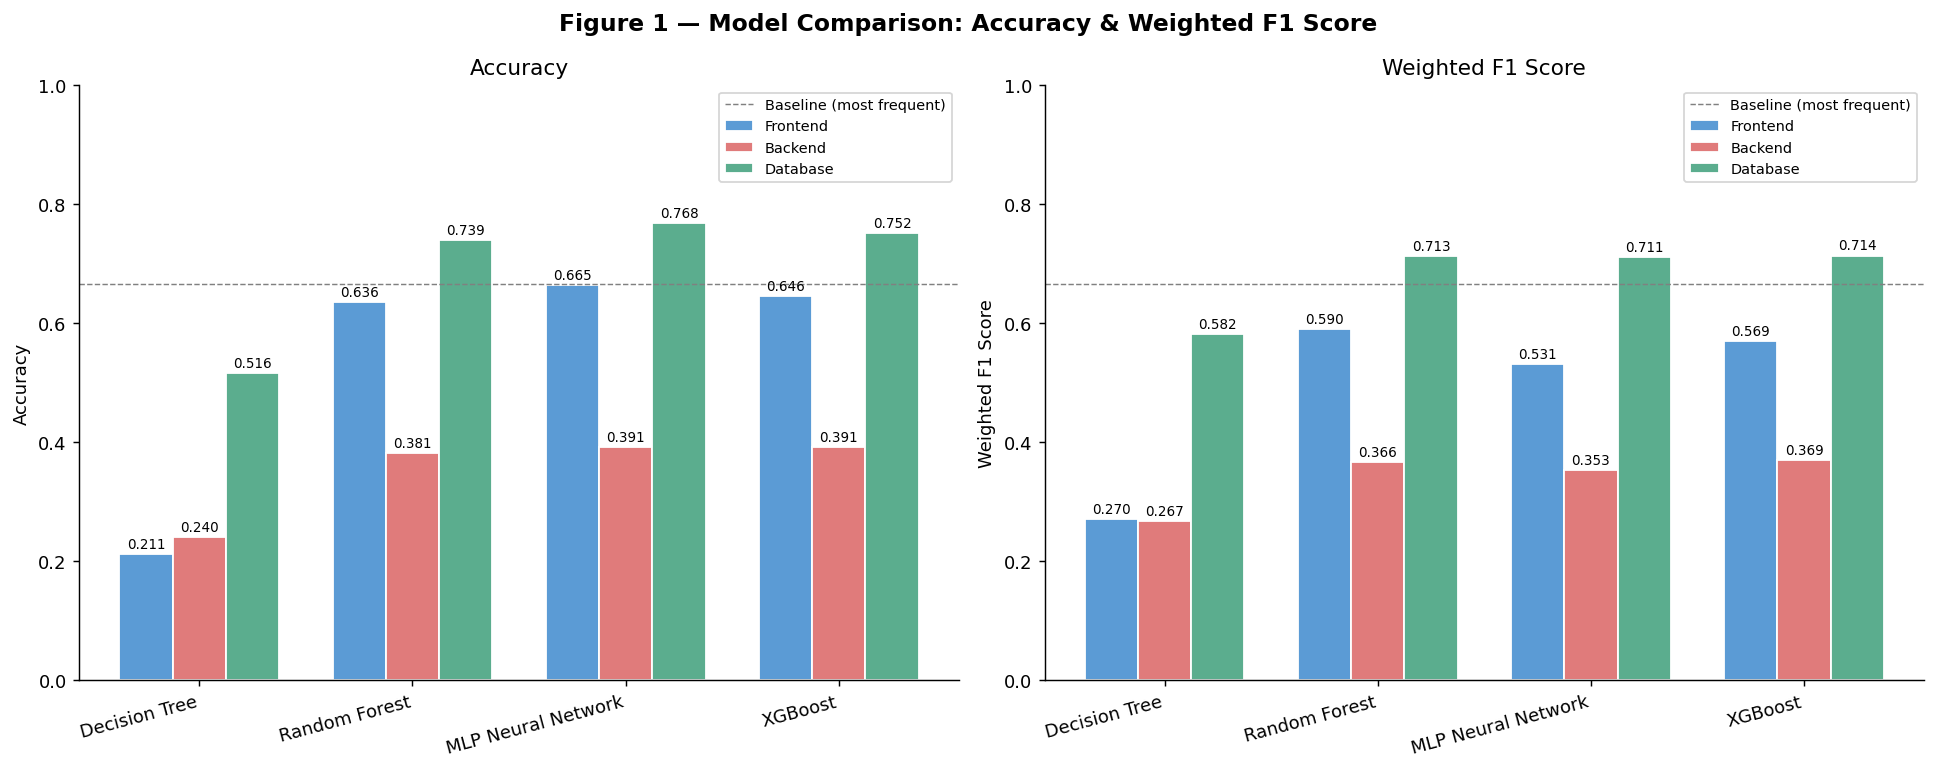

✓ Chart 1 saved → model_01_accuracy_comparison.png


In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 7 ─ CHART 1: Accuracy comparison bar chart
# ══════════════════════════════════════════════════════════════
model_names = list(MODELS.keys())
targets     = ["Frontend","Backend","Database"]
colors      = ["#5B9BD5","#E07B7B","#5BAD8E"]

x     = np.arange(len(model_names))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Figure 1 — Model Comparison: Accuracy & Weighted F1 Score",
             fontsize=13, fontweight="bold")

for ax, metric, ylabel in zip(axes, ["accuracy","f1_weighted"],
                               ["Accuracy","Weighted F1 Score"]):
    for ti, (tname, color) in enumerate(zip(targets, colors)):
        vals = [results[m][tname][metric] for m in model_names]
        bars = ax.bar(x + (ti - 1) * width, vals, width,
                      label=tname, color=color, edgecolor="white")
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.005,
                    f"{v:.3f}", ha="center", va="bottom", fontsize=7.5)

    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=15, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.set_ylim(0, 1.0)
    ax.axhline(y=0.665, color="gray", linestyle="--",
               linewidth=0.8, label="Baseline (most frequent)")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("model_01_accuracy_comparison.png", bbox_inches="tight")
plt.show()
print("✓ Chart 1 saved → model_01_accuracy_comparison.png")


Generating confusion matrices for best model: MLP Neural Network


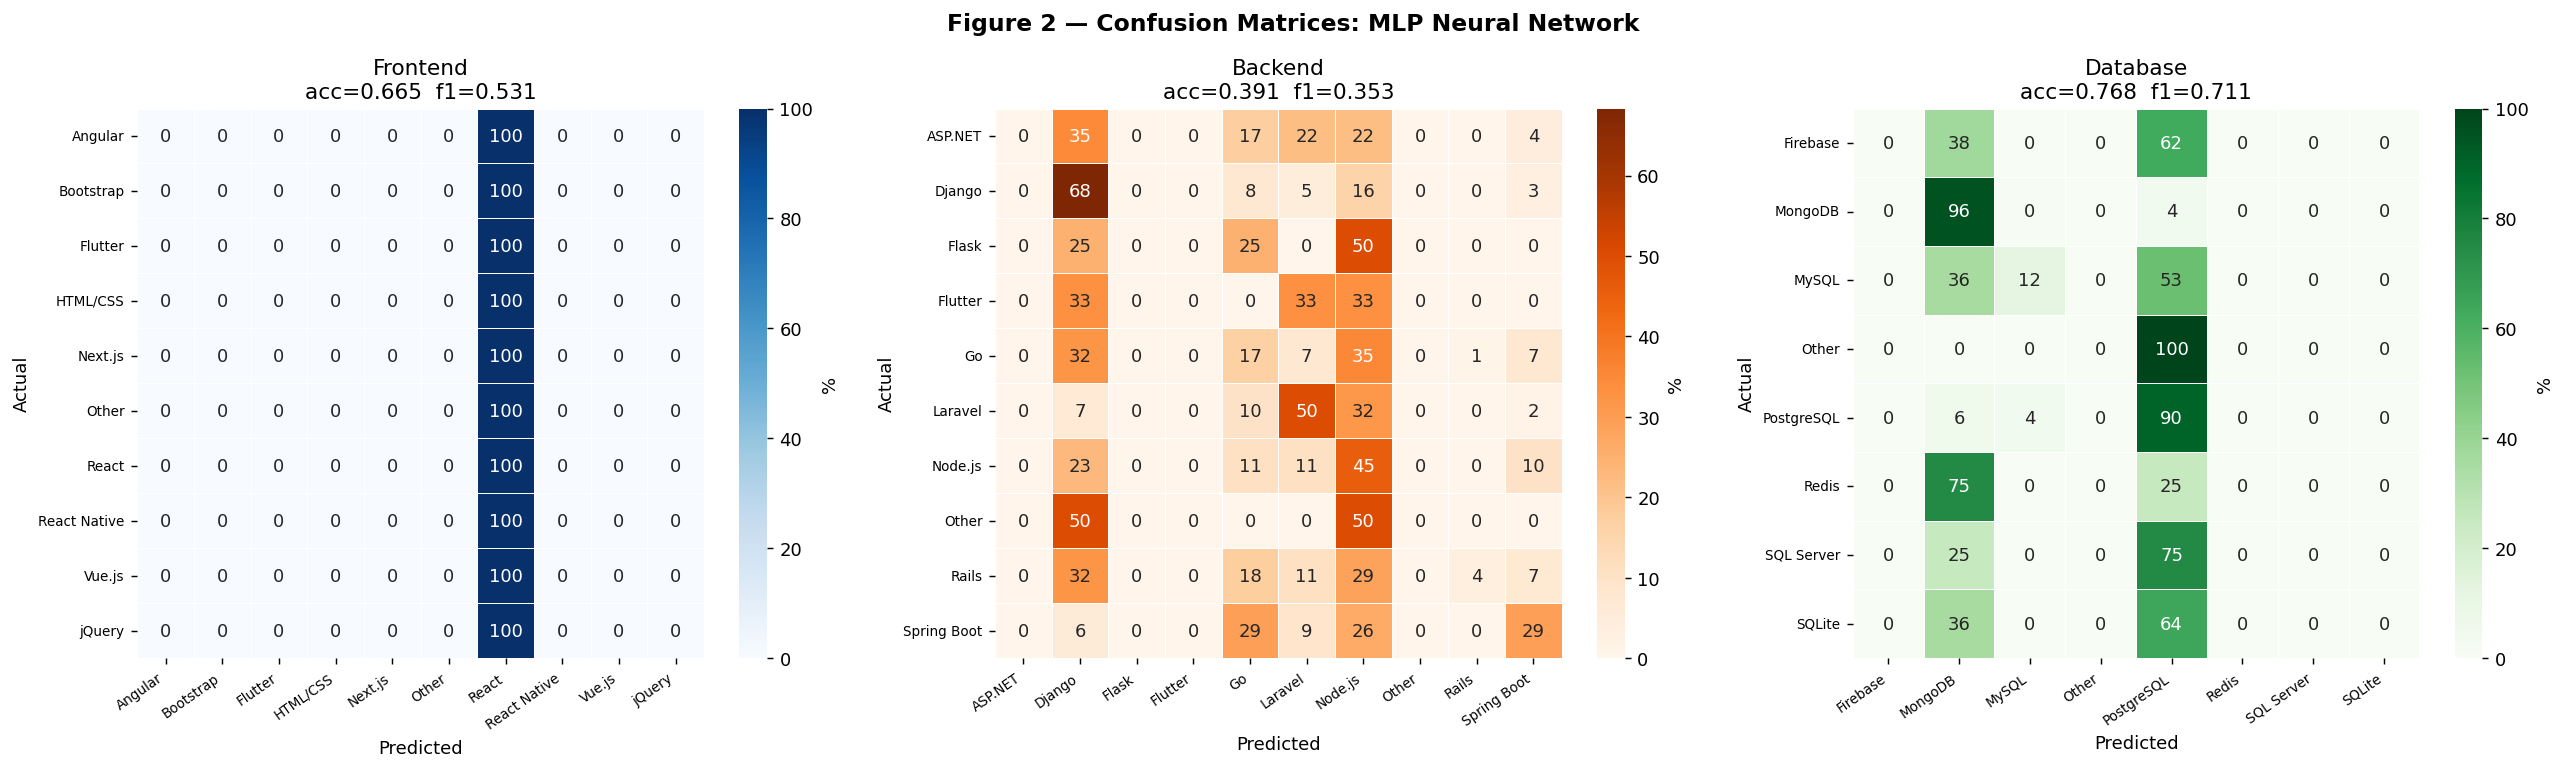

✓ Chart 2 saved → model_02_confusion_matrices.png


In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 8 ─ CHART 2: Confusion matrices for best model
# ══════════════════════════════════════════════════════════════
# Use the model with best average accuracy
best_model_name = summary_df.iloc[0]["Model"]
print(f"\nGenerating confusion matrices for best model: {best_model_name}")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(f"Figure 2 — Confusion Matrices: {best_model_name}",
             fontsize=13, fontweight="bold")

cmap_list = ["Blues","Oranges","Greens"]
for ax, (tname, (_, y_test, le)), cmap in zip(axes, TARGETS.items(), cmap_list):
    model  = trained[best_model_name][tname]
    y_pred = model.predict(X_test)
    cm     = confusion_matrix(y_test, y_pred)

    # Normalise to percentages
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    sns.heatmap(cm_pct, annot=True, fmt=".0f", cmap=cmap,
                xticklabels=le.classes_,
                yticklabels=le.classes_,
                linewidths=0.4, linecolor="white",
                cbar_kws={"label":"%"},
                ax=ax)
    ax.set_title(f"{tname}\nacc={results[best_model_name][tname]['accuracy']:.3f}  "
                 f"f1={results[best_model_name][tname]['f1_weighted']:.3f}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    plt.setp(ax.get_xticklabels(), rotation=35, ha="right", fontsize=7.5)
    plt.setp(ax.get_yticklabels(), rotation=0,  fontsize=7.5)

plt.tight_layout()
plt.savefig("model_02_confusion_matrices.png", bbox_inches="tight")
plt.show()
print("✓ Chart 2 saved → model_02_confusion_matrices.png")


Feature importance from: XGBoost


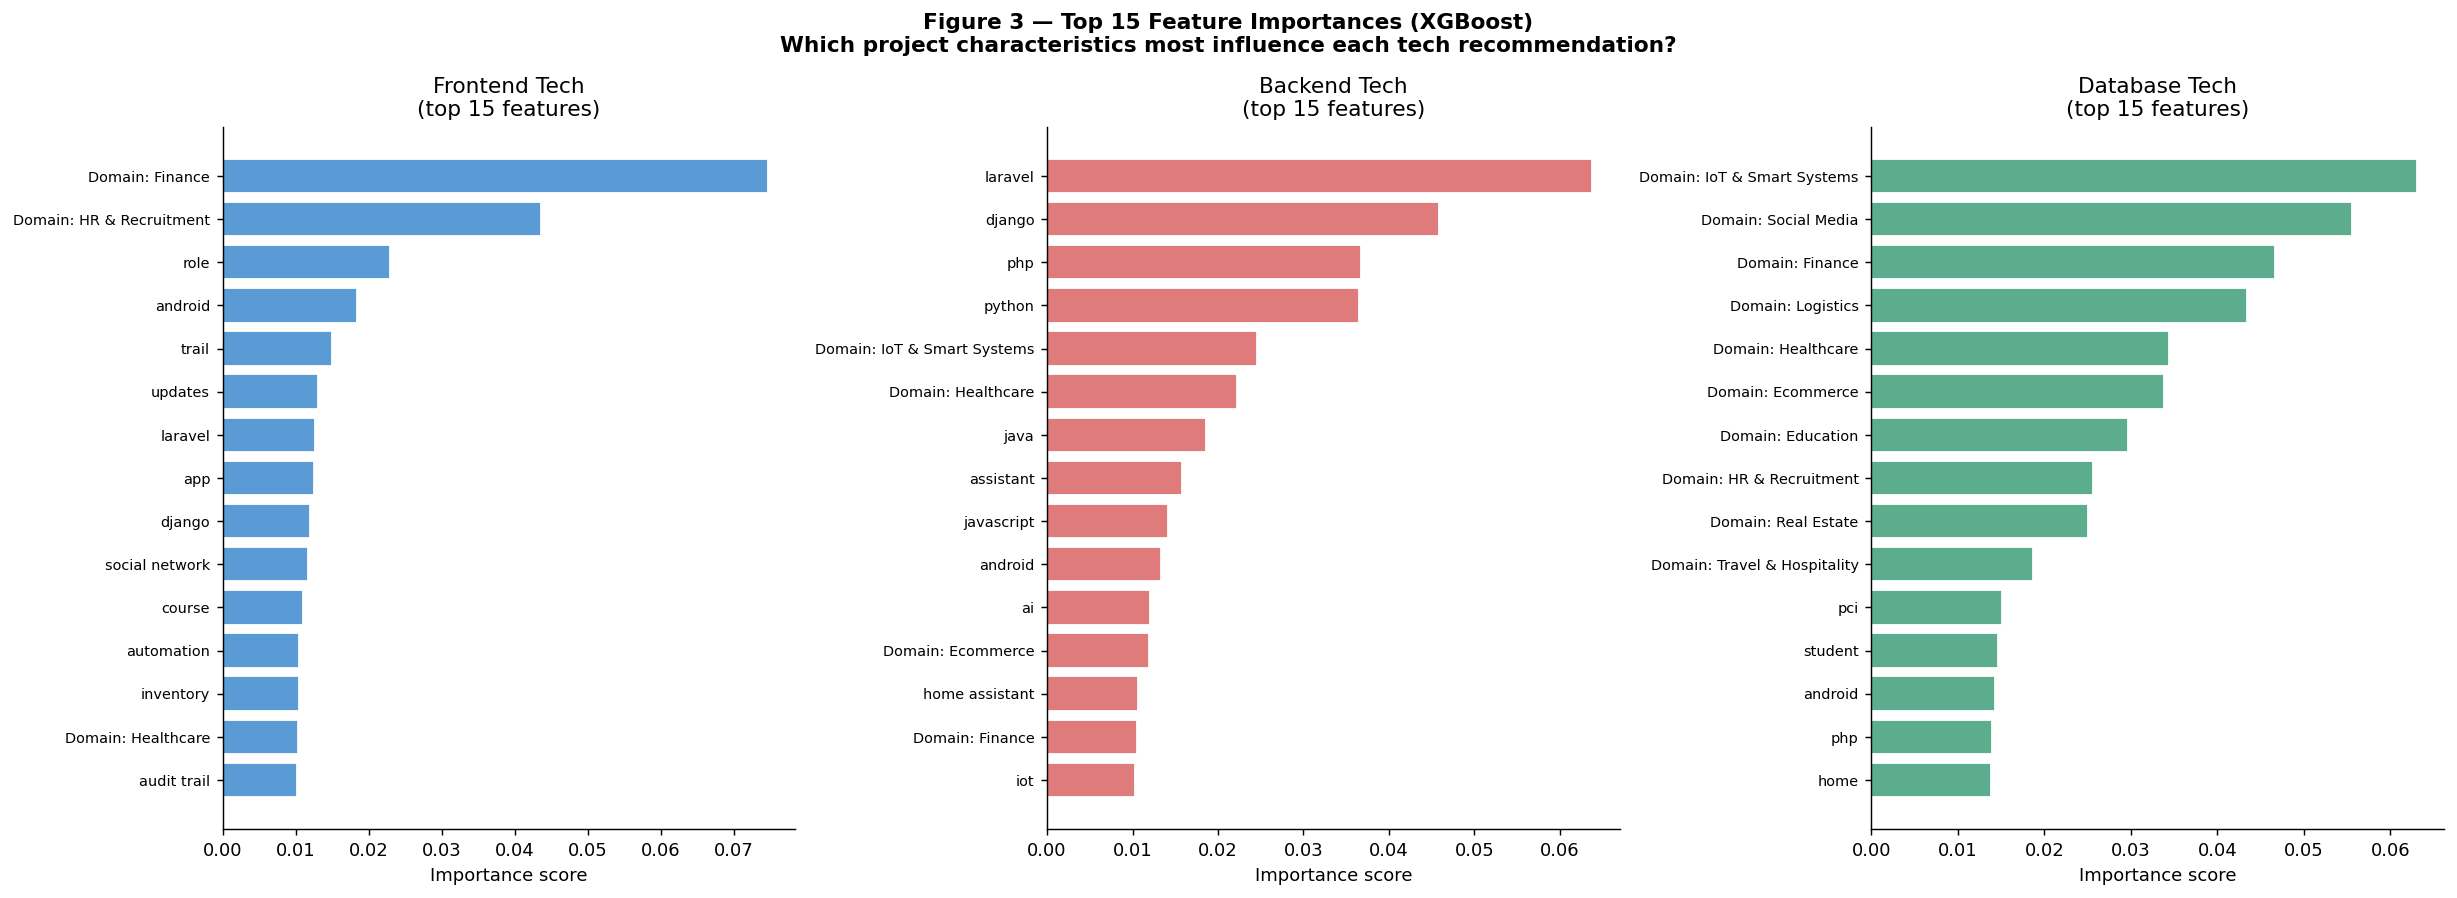

✓ Chart 3 saved → model_03_feature_importance.png

📊 Top 5 features by target:

  Frontend:
    domain:Finance            0.0747
    domain:HR & Recruitment   0.0436
    role                      0.0229
    android                   0.0184
    trail                     0.0150

  Backend:
    laravel                   0.0638
    django                    0.0458
    php                       0.0368
    python                    0.0365
    domain:IoT & Smart Systems 0.0246

  Database:
    domain:IoT & Smart Systems 0.0630
    domain:Social Media       0.0556
    domain:Finance            0.0466
    domain:Logistics          0.0435
    domain:Healthcare         0.0344


In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 9 ─ CHART 3: Feature importance (Random Forest / XGBoost)
# ══════════════════════════════════════════════════════════════
# Which features matter most for predicting each tech?
# This directly answers RQ5 — explainability.

FI_MODEL = "XGBoost" if XGBOOST_AVAILABLE else "Random Forest"
print(f"\nFeature importance from: {FI_MODEL}")

fig, axes = plt.subplots(1, 3, figsize=(19, 7))
fig.suptitle(f"Figure 3 — Top 15 Feature Importances ({FI_MODEL})\n"
             "Which project characteristics most influence each tech recommendation?",
             fontsize=12, fontweight="bold")

feat_arr = np.array(feat_names)
colors   = ["#5B9BD5","#E07B7B","#5BAD8E"]

for ax, (tname, color) in zip(axes, zip(["Frontend","Backend","Database"], colors)):
    model     = trained[FI_MODEL][tname]
    imp       = model.feature_importances_
    top15_idx = np.argsort(imp)[::-1][:15]
    top15_imp = imp[top15_idx]
    top15_nm  = feat_arr[top15_idx]

    # Clean feature names for display
    labels = []
    for n in top15_nm:
        n = n.replace("tfidf_","").replace("dom_","Domain: ").replace("_enc","")
        labels.append(n)

    ax.barh(range(15), top15_imp[::-1], color=color, edgecolor="white")
    ax.set_yticks(range(15))
    ax.set_yticklabels(labels[::-1], fontsize=8)
    ax.set_title(f"{tname} Tech\n(top 15 features)")
    ax.set_xlabel("Importance score")

plt.tight_layout()
plt.savefig("model_03_feature_importance.png", bbox_inches="tight")
plt.show()
print("✓ Chart 3 saved → model_03_feature_importance.png")

# Print top 5 features per target
print("\n📊 Top 5 features by target:")
for tname in ["Frontend","Backend","Database"]:
    model = trained[FI_MODEL][tname]
    imp   = model.feature_importances_
    top5  = np.argsort(imp)[::-1][:5]
    print(f"\n  {tname}:")
    for idx in top5:
        nm = feat_names[idx].replace("tfidf_","").replace("dom_","domain:").replace("_enc","")
        print(f"    {nm:<25} {imp[idx]:.4f}")


5-fold cross-validation (Frontend only — takes ~2 min)...
  Decision Tree          CV acc = 0.205 ± 0.029
  Random Forest          CV acc = 0.619 ± 0.017
  MLP Neural Network     CV acc = 0.666 ± 0.004
  XGBoost                CV acc = 0.646 ± 0.013


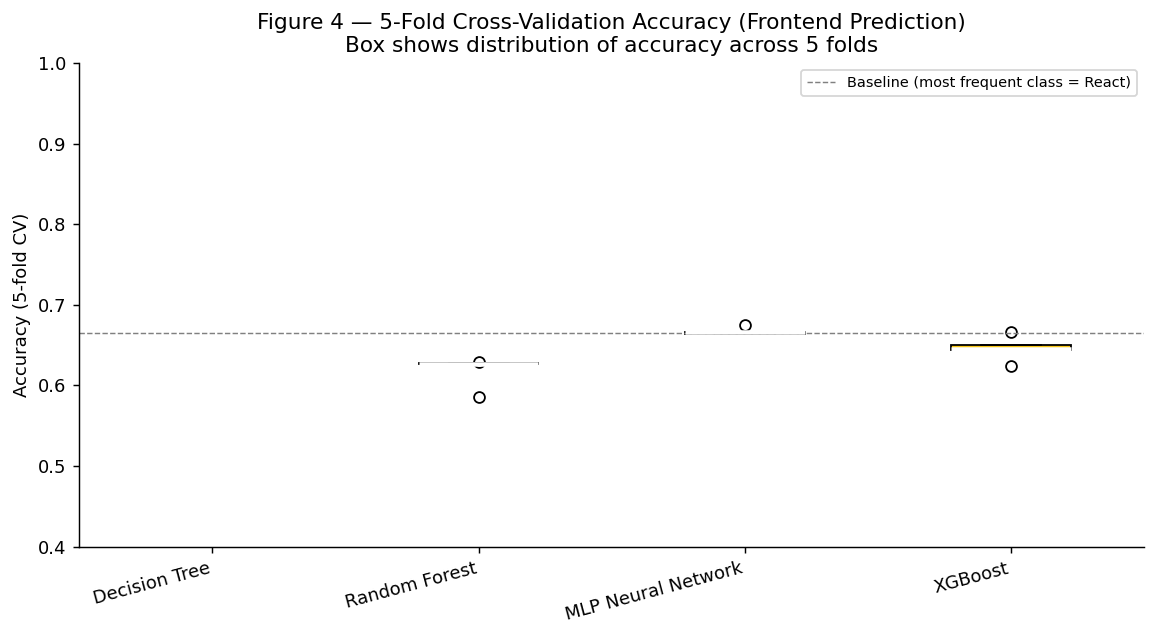

✓ Chart 4 saved → model_04_cross_validation.png


In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 10 ─ CHART 4: Cross-validation scores
# ══════════════════════════════════════════════════════════════
# 5-fold CV gives a more reliable accuracy estimate than a
# single train/test split. This is standard practice in ML.

print("\n5-fold cross-validation (Frontend only — takes ~2 min)...")

cv_results = {}
for mname, model_template in MODELS.items():
    import copy
    model  = copy.deepcopy(model_template)
    cv_scores = cross_val_score(model, X_train, y_fe_train,
                                 cv=5, scoring="accuracy", n_jobs=-1)
    cv_results[mname] = cv_scores
    print(f"  {mname:<22} CV acc = {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

fig, ax = plt.subplots(figsize=(9, 5))
positions = range(len(MODELS))
bp = ax.boxplot([cv_results[m] for m in MODELS.keys()],
                positions=positions,
                patch_artist=True,
                medianprops={"color":"white","linewidth":2.5})

box_colors = ["#5B9BD5","#E07B7B","#5BAD8E","#F5C518"]
for patch, color in zip(bp["boxes"], box_colors):
    patch.set_facecolor(color)

ax.set_xticks(positions)
ax.set_xticklabels(list(MODELS.keys()), rotation=15, ha="right")
ax.set_ylabel("Accuracy (5-fold CV)")
ax.set_title("Figure 4 — 5-Fold Cross-Validation Accuracy (Frontend Prediction)\n"
             "Box shows distribution of accuracy across 5 folds")
ax.axhline(y=0.665, color="gray", linestyle="--", linewidth=0.8,
           label="Baseline (most frequent class = React)")
ax.set_ylim(0.4, 1.0)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("model_04_cross_validation.png", bbox_inches="tight")
plt.show()
print("✓ Chart 4 saved → model_04_cross_validation.png")

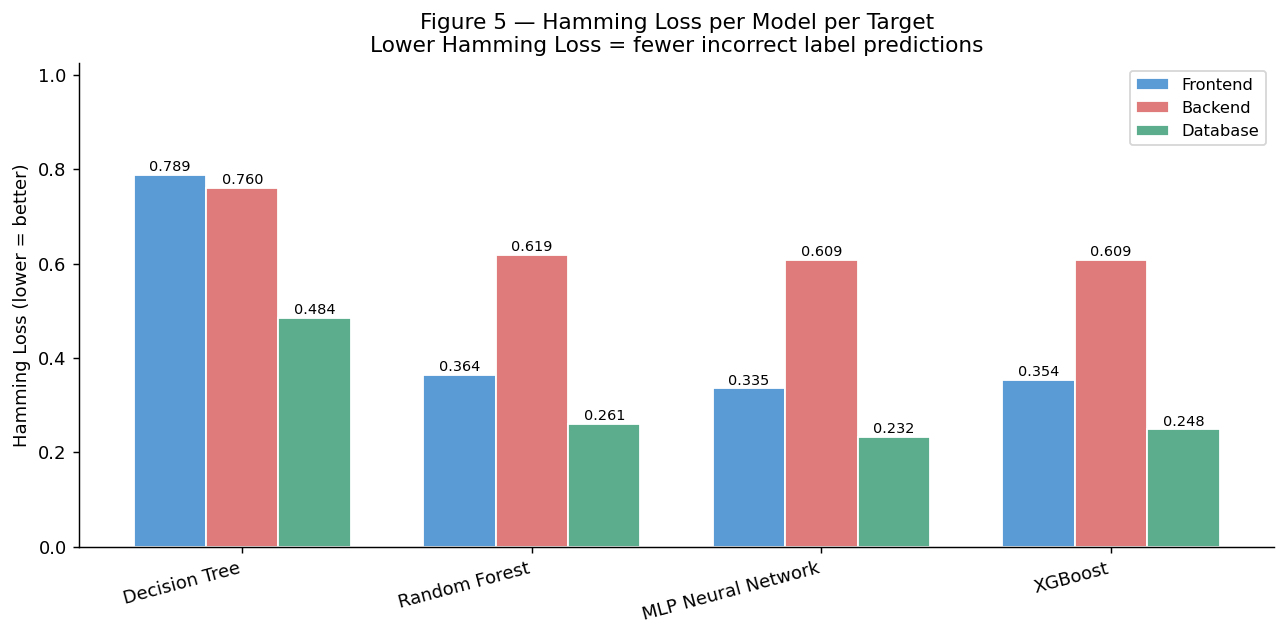

✓ Chart 5 saved → model_05_hamming_loss.png


In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 11 ─ CHART 5: Hamming loss comparison
# ══════════════════════════════════════════════════════════════
# Hamming loss = fraction of labels predicted incorrectly.
# Lower is better. For multi-output problems this is the
# standard metric (mentioned in your proposal).

fig, ax = plt.subplots(figsize=(10, 5))

x     = np.arange(len(MODELS))
width = 0.25
tnames = ["Frontend","Backend","Database"]
colors = ["#5B9BD5","#E07B7B","#5BAD8E"]

for ti, (tname, color) in enumerate(zip(tnames, colors)):
    vals = [results[m][tname]["hamming"] for m in MODELS.keys()]
    bars = ax.bar(x + (ti-1)*width, vals, width,
                  label=tname, color=color, edgecolor="white")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.002,
                f"{v:.3f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(list(MODELS.keys()), rotation=15, ha="right")
ax.set_ylabel("Hamming Loss (lower = better)")
ax.set_title("Figure 5 — Hamming Loss per Model per Target\n"
             "Lower Hamming Loss = fewer incorrect label predictions")
ax.legend(fontsize=9)
ax.set_ylim(0, max(results[m][t]["hamming"]
                   for m in MODELS for t in tnames) * 1.3)
plt.tight_layout()
plt.savefig("model_05_hamming_loss.png", bbox_inches="tight")
plt.show()
print("✓ Chart 5 saved → model_05_hamming_loss.png")

In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 12 ─ Save the best model
# ══════════════════════════════════════════════════════════════
best_name  = summary_df.iloc[0]["Model"]
best_fe    = trained[best_name]["Frontend"]
best_be    = trained[best_name]["Backend"]
best_db    = trained[best_name]["Database"]

joblib.dump({
    "model_name":  best_name,
    "frontend":    best_fe,
    "backend":     best_be,
    "database":    best_db,
    "le_fe":       le_fe,
    "le_be":       le_be,
    "le_db":       le_db,
    "feat_names":  feat_names,
    "results":     results,
}, "best_model.pkl")

# Also save all models
joblib.dump(trained,  "all_trained_models.pkl")
joblib.dump(results,  "all_results.pkl")

print(f"✓ Best model saved → best_model.pkl  [{best_name}]")
print("✓ All models saved → all_trained_models.pkl")
print("✓ All results saved → all_results.pkl")

✓ Best model saved → best_model.pkl  [MLP Neural Network]
✓ All models saved → all_trained_models.pkl
✓ All results saved → all_results.pkl


In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 13 ─ Quick prediction demo
# ══════════════════════════════════════════════════════════════
# Verify the model works end-to-end on a sample new project

print("\n" + "=" * 55)
print("  DEMO: Predict stack for a sample new project")
print("=" * 55)

# Take one row from test set and show prediction vs actual
sample_idx = 10
X_sample   = X_test.iloc[[sample_idx]]

fe_pred = le_fe.inverse_transform(best_fe.predict(X_sample))[0]
be_pred = le_be.inverse_transform(best_be.predict(X_sample))[0]
db_pred = le_db.inverse_transform(best_db.predict(X_sample))[0]

fe_true = le_fe.inverse_transform([y_fe_test[sample_idx]])[0]
be_true = le_be.inverse_transform([y_be_test[sample_idx]])[0]
db_true = le_db.inverse_transform([y_db_test[sample_idx]])[0]

print(f"\n  {'Target':<12} {'Predicted':<18} {'Actual':<18} {'Correct?'}")
print(f"  {'─'*60}")
for label, pred, true in [("Frontend",fe_pred,fe_true),
                            ("Backend", be_pred,be_true),
                            ("Database",db_pred,db_true)]:
    ok = "✓" if pred == true else "✗"
    print(f"  {label:<12} {pred:<18} {true:<18} {ok}")


  DEMO: Predict stack for a sample new project

  Target       Predicted          Actual             Correct?
  ────────────────────────────────────────────────────────────
  Frontend     React              React              ✓
  Backend      Django             Go                 ✗
  Database     PostgreSQL         PostgreSQL         ✓


In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 14 ─ Final results summary
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("  MODEL TRAINING COMPLETE — FINAL SUMMARY")
print("=" * 65)
print(f"\n  Training data     : {X_train.shape[0]:,} samples × {X_train.shape[1]} features")
print(f"  Test data         : {X_test.shape[0]:,} samples")
print(f"  Models trained    : {len(MODELS)} × 3 targets = {len(MODELS)*3} classifiers")
print(f"\n  Results table:")
print(f"  {'Model':<22} {'Avg Acc':>8} {'FE Acc':>8} {'BE Acc':>8} {'DB Acc':>8}")
print(f"  {'─'*56}")
for _, row in summary_df.iterrows():
    print(f"  {row['Model']:<22} {row['Avg Acc']:>8.3f} "
          f"{row['Frontend Acc']:>8.3f} {row['Backend Acc']:>8.3f} "
          f"{row['Database Acc']:>8.3f}")
print(f"\n  Best model        : {best_name}")
print(f"  Baseline accuracy : 0.665 (always predict React)")
print(f"\n  Note: Backend accuracy (~40%) is lower because 10")
print(f"  backend technologies are more similar to each other")
print(f"  than frontend/database — this is a known challenge")
print(f"  in multi-class classification with overlapping classes.")

print(f"\n  Answers to research questions:")
print(f"  RQ3 → Best ML technique: {best_name}")
print(f"  RQ4 → Full stack prediction accuracy: see results table")
print(f"  RQ5 → Feature importance chart shows WHY each tech is chosen")
print("=" * 65)


  MODEL TRAINING COMPLETE — FINAL SUMMARY

  Training data     : 1,931 samples × 115 features
  Test data         : 483 samples
  Models trained    : 4 × 3 targets = 12 classifiers

  Results table:
  Model                   Avg Acc   FE Acc   BE Acc   DB Acc
  ────────────────────────────────────────────────────────
  MLP Neural Network        0.608    0.665    0.391    0.768
  XGBoost                   0.596    0.646    0.391    0.752
  Random Forest             0.585    0.636    0.381    0.739
  Decision Tree             0.322    0.211    0.240    0.516

  Best model        : MLP Neural Network
  Baseline accuracy : 0.665 (always predict React)

  Note: Backend accuracy (~40%) is lower because 10
  backend technologies are more similar to each other
  than frontend/database — this is a known challenge
  in multi-class classification with overlapping classes.

  Answers to research questions:
  RQ3 → Best ML technique: MLP Neural Network
  RQ4 → Full stack prediction accuracy: see r

In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 15 ─ Download all outputs
# ══════════════════════════════════════════════════════════════
OUTPUT_FILES = [
    "best_model.pkl",
    "all_trained_models.pkl",
    "all_results.pkl",
    "model_comparison.csv",
    "model_01_accuracy_comparison.png",
    "model_02_confusion_matrices.png",
    "model_03_feature_importance.png",
    "model_04_cross_validation.png",
    "model_05_hamming_loss.png",
]

for f in OUTPUT_FILES:
    if os.path.exists(f):
        files.download(f)
        print(f"  ⬇ {f}")

print(f"\n✓ All outputs downloaded.")
print("  Next step: say 'Guide me through model evaluation and SHAP explainability'")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ⬇ best_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ⬇ model_04_cross_validation.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ⬇ model_05_hamming_loss.png

✓ All outputs downloaded.
  Next step: say 'Guide me through model evaluation and SHAP explainability'
